In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

history = pd.read_csv(
    "../data/processed/asset_history_simulated.csv"
)

failures = pd.read_csv(
    "../data/processed/failures_simulated.csv"
)

print("History shape:", history.shape)
print("Failures shape:", failures.shape)

display(history.head())
display(failures.head())\

History shape: (92000, 10)
Failures shape: (1048, 7)


,asset_id,section_id,department,asset_type,snapshot_date,asset_age_years,condition_score,criticality,usage_factor,weather_stress
0,ASSET00001,RTM-VAD-01,TRACTION,OHE,2019-01-01,8,93.126212,6,0.565548,0.416271
1,ASSET00001,RTM-VAD-01,TRACTION,OHE,2019-02-01,8,92.456850,6,0.565548,0.087173
2,ASSET00001,RTM-VAD-01,TRACTION,OHE,2019-03-01,8,95.602455,6,0.565548,0.899679
3,ASSET00001,RTM-VAD-01,TRACTION,OHE,2019-04-01,8,96.610857,6,0.565548,0.408667
4,ASSET00001,RTM-VAD-01,TRACTION,OHE,2019-05-01,8,94.519420,6,0.565548,0.391072


,failure_id,asset_id,failure_date,failure_type,severity,downtime_hours,repair_duration_hours
0,FAIL000001,ASSET00002,2021-12-01,OHE_FAILURE,7,11.819226,4.491025
1,FAIL000002,ASSET00003,2025-01-01,SIGNAL_FAILURE,6,9.214649,6.461841
2,FAIL000003,ASSET00003,2025-05-01,OHE_FAILURE,5,1.167383,6.360502
3,FAIL000004,ASSET00005,2022-01-01,TRACK_FAILURE,8,3.626038,4.412465
4,FAIL000005,ASSET00006,2024-07-01,OHE_FAILURE,9,2.429383,4.656178


In [2]:
print("History columns:")
print(history.columns.tolist())

print("\nFailure columns:")
print(failures.columns.tolist())

History columns:
['asset_id', 'section_id', 'department', 'asset_type', 'snapshot_date', 'asset_age_years', 'condition_score', 'criticality', 'usage_factor', 'weather_stress']

Failure columns:
['failure_id', 'asset_id', 'failure_date', 'failure_type', 'severity', 'downtime_hours', 'repair_duration_hours']


In [3]:
history["snapshot_date"] = pd.to_datetime(
    history["snapshot_date"]
)

failures["failure_date"] = pd.to_datetime(
    failures["failure_date"]
)

history = history.sort_values(
    ["asset_id", "snapshot_date"]
).reset_index(drop=True)

failures = failures.sort_values(
    ["asset_id", "failure_date"]
).reset_index(drop=True)

print("Dates converted successfully.")

Dates converted successfully.


In [4]:
def calculate_rul(row):
    asset_failures = failures[
        failures["asset_id"] == row["asset_id"]
    ]

    future_failures = asset_failures[
        asset_failures["failure_date"] > row["snapshot_date"]
    ]

    if len(future_failures) == 0:
        return np.nan

    next_failure = future_failures[
        "failure_date"
    ].min()

    return (
        next_failure - row["snapshot_date"]
    ).days


history["rul_days"] = history.apply(
    calculate_rul,
    axis=1
)

print("RUL target created.")

display(
    history[
        [
            "asset_id",
            "snapshot_date",
            "condition_score",
            "rul_days"
        ]
    ].head(20)
)

RUL target created.


,asset_id,snapshot_date,condition_score,rul_days
0,ASSET00001,2019-01-01,93.126212,NaN
1,ASSET00001,2019-02-01,92.456850,NaN
2,ASSET00001,2019-03-01,95.602455,NaN
3,ASSET00001,2019-04-01,96.610857,NaN
4,ASSET00001,2019-05-01,94.519420,NaN
5,ASSET00001,2019-06-01,94.714184,NaN
6,ASSET00001,2019-07-01,98.417893,NaN
7,ASSET00001,2019-08-01,91.194071,NaN
8,ASSET00001,2019-09-01,92.403716,NaN
9,ASSET00001,2019-10-01,94.520897,NaN


In [5]:
print(
    history["rul_days"].describe()
)

count    34284.000000
mean       790.813207
std        601.519843
min         28.000000
25%        304.000000
50%        641.000000
75%       1158.000000
max       2769.000000
Name: rul_days, dtype: float64


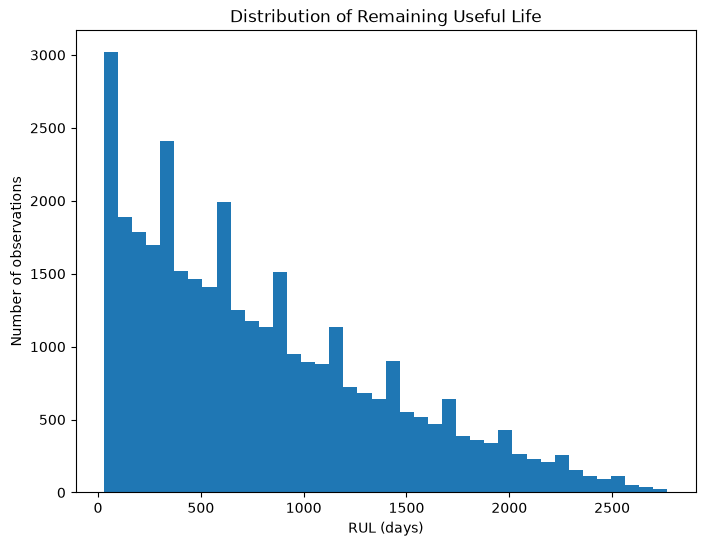

In [6]:
plt.figure(figsize=(8, 6))

plt.hist(
    history["rul_days"].dropna(),
    bins=40
)

plt.xlabel("RUL (days)")
plt.ylabel("Number of observations")
plt.title("Distribution of Remaining Useful Life")

plt.show()

In [7]:
history["rul_days"] = history["rul_days"].clip(
    upper=365
)

In [8]:
rul_data = history[
    history["rul_days"].notna()
].copy()

print("RUL training observations:", len(rul_data))

RUL training observations: 34284


In [9]:
rul_features = [
    "asset_age_years",
    "condition_score",
    "criticality",
    "usage_factor",
    "weather_stress"
]

rul_target = "rul_days"

X_rul = rul_data[rul_features]
y_rul = rul_data[rul_target]

print("RUL features:")
print(rul_features)

print("\nTarget:")
print(rul_target)

print("\nShape:", X_rul.shape)

RUL features:
['asset_age_years', 'condition_score', 'criticality', 'usage_factor', 'weather_stress']

Target:
rul_days

Shape: (34284, 5)


In [10]:
split_date = pd.Timestamp("2025-01-01")

rul_train = rul_data[
    rul_data["snapshot_date"] < split_date
].copy()

rul_test = rul_data[
    rul_data["snapshot_date"] >= split_date
].copy()

print("RUL training rows:", len(rul_train))
print("RUL testing rows:", len(rul_test))

print(
    "\nTraining date range:",
    rul_train["snapshot_date"].min(),
    "to",
    rul_train["snapshot_date"].max()
)

print(
    "Testing date range:",
    rul_test["snapshot_date"].min(),
    "to",
    rul_test["snapshot_date"].max()
)

RUL training rows: 31922
RUL testing rows: 2362

Training date range: 2019-01-01 00:00:00 to 2024-12-01 00:00:00
Testing date range: 2025-01-01 00:00:00 to 2026-07-01 00:00:00


In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

X_rul_train = rul_train[rul_features]
y_rul_train = rul_train[rul_target]

X_rul_test = rul_test[rul_features]
y_rul_test = rul_test[rul_target]

rul_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rul_model.fit(
    X_rul_train,
    y_rul_train
)

rul_predictions = rul_model.predict(
    X_rul_test
)

print("RUL model trained successfully.")

RUL model trained successfully.


In [12]:
rul_mae = mean_absolute_error(
    y_rul_test,
    rul_predictions
)

rul_rmse = np.sqrt(
    mean_squared_error(
        y_rul_test,
        rul_predictions
    )
)

rul_r2 = r2_score(
    y_rul_test,
    rul_predictions
)

print("RUL Model Performance")
print("---------------------")
print("MAE :", round(rul_mae, 2), "days")
print("RMSE:", round(rul_rmse, 2), "days")
print("R²  :", round(rul_r2, 3))

RUL Model Performance
---------------------
MAE : 134.92 days
RMSE: 161.61 days
R²  : -0.916


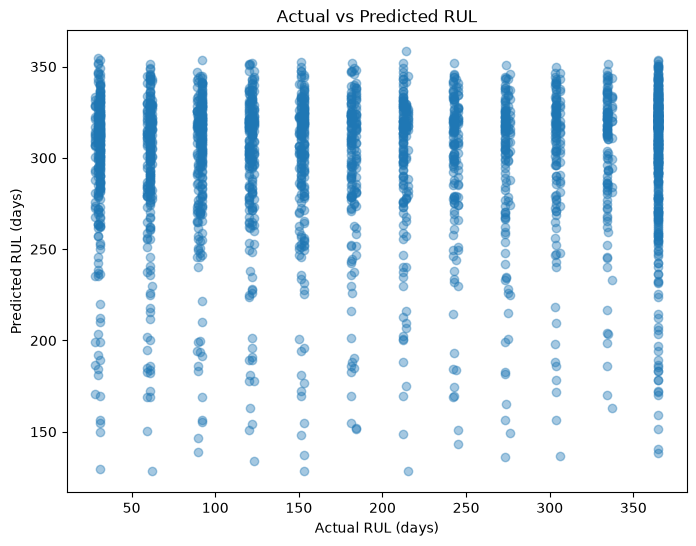

In [13]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_rul_test,
    rul_predictions,
    alpha=0.4
)

plt.xlabel("Actual RUL (days)")
plt.ylabel("Predicted RUL (days)")
plt.title("Actual vs Predicted RUL")

plt.show()

In [14]:
rul_importance = pd.DataFrame({
    "feature": rul_features,
    "importance": rul_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

display(rul_importance)

,feature,importance
1,condition_score,0.269394
0,asset_age_years,0.225962
4,weather_stress,0.191384
3,usage_factor,0.173921
2,criticality,0.139340


In [15]:
rul_results = rul_test[
    [
        "asset_id",
        "snapshot_date",
        "section_id",
        "asset_type",
        "department",
        "asset_age_years",
        "condition_score",
        "criticality",
        "usage_factor",
        "weather_stress",
        "rul_days"
    ]
].copy()

rul_results["predicted_rul_days"] = rul_predictions

rul_results["rul_error_days"] = (
    rul_results["predicted_rul_days"]
    - rul_results["rul_days"]
)

display(
    rul_results.head(20)
)

,asset_id,snapshot_date,section_id,asset_type,department,asset_age_years,condition_score,criticality,usage_factor,weather_stress,rul_days,predicted_rul_days,rul_error_days
256,ASSET00003,2025-01-01,MTJ-AGC-01,SIGNAL,S&T,9,86.047498,10,0.909819,0.726347,120.0,321.965341,201.965341
257,ASSET00003,2025-02-01,MTJ-AGC-01,SIGNAL,S&T,9,74.100683,10,0.909819,0.335367,89.0,317.703212,228.703212
258,ASSET00003,2025-03-01,MTJ-AGC-01,SIGNAL,S&T,9,82.186654,10,0.909819,0.225990,61.0,324.232478,263.232478
259,ASSET00003,2025-04-01,MTJ-AGC-01,SIGNAL,S&T,9,83.419282,10,0.909819,0.550709,30.0,316.461658,286.461658
1544,ASSET00017,2025-01-01,RTM-VAD-01,OHE,TRACTION,5,76.102823,9,0.565548,0.235294,273.0,331.711946,58.711946
1545,ASSET00017,2025-02-01,RTM-VAD-01,OHE,TRACTION,5,82.002672,9,0.565548,0.682232,242.0,295.531216,53.531216
1546,ASSET00017,2025-03-01,RTM-VAD-01,OHE,TRACTION,5,78.745534,9,0.565548,0.324338,214.0,312.157492,98.157492
1547,ASSET00017,2025-04-01,RTM-VAD-01,OHE,TRACTION,5,87.651259,9,0.565548,0.083314,183.0,282.188553,99.188553
1548,ASSET00017,2025-05-01,RTM-VAD-01,OHE,TRACTION,5,81.259314,9,0.565548,0.628518,153.0,300.425427,147.425427
1549,ASSET00017,2025-06-01,RTM-VAD-01,OHE,TRACTION,5,77.876935,9,0.565548,0.311284,122.0,321.635936,199.635936


In [16]:
rul_results.to_csv(
    "../data/predictions/rul_predictions.csv",
    index=False
)

print(
    "Saved:",
    "../data/predictions/rul_predictions.csv"
)

Saved: ../data/predictions/rul_predictions.csv
